# Structured Nonlinear Metamaterials: Photon Correlation Simulation
### Effect of Spatial χ⁽²⁾ Crystal Structuring on Quantum Photon Pair Correlations
**Course:** UE23EC343BB1  
**Topic:** Quantum Nonlinear Optics — SPDC Simulation Suite  
**Description:** Full simulation of how spatial crystal structuring controls both spatial and spectral correlations of SPDC photon pairs. Covers five modulation profiles, Phase Matching Functions, Joint Spectral Intensity, spatial photon correlation maps, OAM mode analysis, Schmidt decomposition, and fabrication error impact.

---
## Figure Index
| Figure | Description |
|--------|-------------|
| Fig 1 | χ⁽²⁾ modulation profiles along crystal |
| Fig 2 | Phase Matching Function |Φ(Δk)|² (individual) |
| Fig 3 | PMF overlay (publication style) |
| Fig 4 | Joint Spectral Intensity — uniform vs Gaussian crystal |
| Fig 5 | PMF metrics table |
| Fig 6 | Fabrication error (RDC) impact |
| Fig 7 | 2D Spatial nonlinear profiles (transverse structuring) |
| Fig 8 | Spatial photon correlation maps |
| Fig 9 | OAM spiral spectrum |
| Fig 10 | Schmidt mode decomposition |
| Fig 11 | Spectral purity vs crystal length |
| Fig 12 | Entanglement entropy vs pump bandwidth |


## Cell 0 — Imports & Style Configuration

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.fft import fft2, fftshift, fftfreq, fft, ifft
from scipy.linalg import svd
from scipy.special import factorial
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 100,
    'axes.grid': False,
})
print('Libraries loaded successfully.')


Libraries loaded successfully.


## Cell 1 — Physical Parameters
We model a PPKTP-like crystal with the following representative parameters.

In [13]:
# ── Crystal parameters ────────────────────────────────────────────────────────
L       = 10e-3          # Crystal length [m] — 10 mm, typical PPKTP
N       = 4096           # Number of discretisation points along z
z       = np.linspace(-L/2, L/2, N)   # Longitudinal coordinate
dz      = z[1] - z[0]

# ── Transverse grid (for 2D spatial simulations) ──────────────────────────────
Nx      = 256
x_max   = 2e-3           # ±2 mm transverse aperture
x       = np.linspace(-x_max, x_max, Nx)
dx      = x[1] - x[0]
XX, ZZ  = np.meshgrid(x, z[:Nx])   # 2D grid (square, Nx×Nx)
XX2, YY2 = np.meshgrid(x, x)       # transverse 2D grid

# ── QPM / phase-matching parameters ───────────────────────────────────────────
Lambda  = 9.3e-6         # Poling period [m]
Gc      = 2*np.pi/Lambda # First-order QPM reciprocal lattice vector

# Phase mismatch scan
Ndk     = 2048
dk_max  = 6 * (2*np.pi / L)
delta_k = np.linspace(-dk_max, dk_max, Ndk)

# Gaussian apodisation width
sigma_g = L / 4.0

# Dispersion parameters (PPKTP at 1560 nm, type-0)
beta2   = -600e-30 / 1e-3   # GVD [s²/m]
c_light = 3e8
n_eff   = 1.74

print(f'Crystal length      : {L*1e3:.1f} mm')
print(f'Poling period Λ     : {Lambda*1e6:.2f} µm')
print(f'QPM vector Gc       : {Gc/1e6:.2f} rad/mm')
print(f'GVD β₂              : {beta2*1e27:.1f} fs²/mm')


Crystal length      : 10.0 mm
Poling period Λ     : 9.30 µm
QPM vector Gc       : 0.68 rad/mm
GVD β₂              : -600.0 fs²/mm


## Cell 2 — Define χ⁽²⁾ Modulation Profiles
Five modulation types spanning uniform, periodic QPM, Gaussian-apodized, chirped, and random-duty-cycle (RDC) error structures.

In [14]:
def d_uniform(z):
    """Uniform (unpoled) crystal."""
    return np.ones_like(z)

def d_periodic_qpm(z, Lambda):
    """Standard periodic QPM: binary ±1 square wave."""
    return np.sign(np.cos(2*np.pi * z / Lambda))

def d_gaussian_apodized(z, Lambda, sigma):
    """Gaussian-apodized QPM via selective domain erasure."""
    G    = np.exp(-z**2 / (2*sigma**2))
    base = np.sign(np.cos(2*np.pi * z / Lambda))
    rng  = np.random.default_rng(42)
    rand = rng.uniform(0, 1, size=z.shape)
    mask = rand < G
    return base * mask.astype(float)

def d_chirped(z, Lambda_start, Lambda_end):
    """Linearly chirped QPM."""
    Lambda_z = Lambda_start + (Lambda_end - Lambda_start) * (z + L/2) / L
    phase    = 2*np.pi * np.cumsum(1.0 / Lambda_z) * (z[1]-z[0])
    return np.sign(np.cos(phase))

def d_random_rdc(z, Lambda, sigma_rdc=0.15):
    """QPM with Random Duty Cycle fabrication errors."""
    rng       = np.random.default_rng(7)
    l_domain  = Lambda / 2
    n_domains = int(L / l_domain) + 2
    edges     = np.cumsum(l_domain + rng.normal(0, sigma_rdc*l_domain, n_domains)) - L/2
    d         = np.ones_like(z)
    for edge in edges:
        d[z > edge] *= -1
    return d

d_unif  = d_uniform(z)
d_qpm   = d_periodic_qpm(z, Lambda)
d_gauss = d_gaussian_apodized(z, Lambda, sigma_g)
d_chirp = d_chirped(z, Lambda*0.85, Lambda*1.15)
d_rdc   = d_random_rdc(z, Lambda, sigma_rdc=0.20)

profiles = {
    'Uniform'          : (d_unif,  '#4A90D9'),
    'Periodic QPM'     : (d_qpm,   '#27AE60'),
    'Gaussian apodized': (d_gauss, '#E67E22'),
    'Chirped QPM'      : (d_chirp, '#8E44AD'),
    'RDC errors (20%)' : (d_rdc,   '#C0392B'),
}
print('All modulation profiles computed.')


All modulation profiles computed.


## Cell 3 — Figure 1: χ⁽²⁾ Nonlinearity Profiles Along Crystal
**Save this image for your report.**

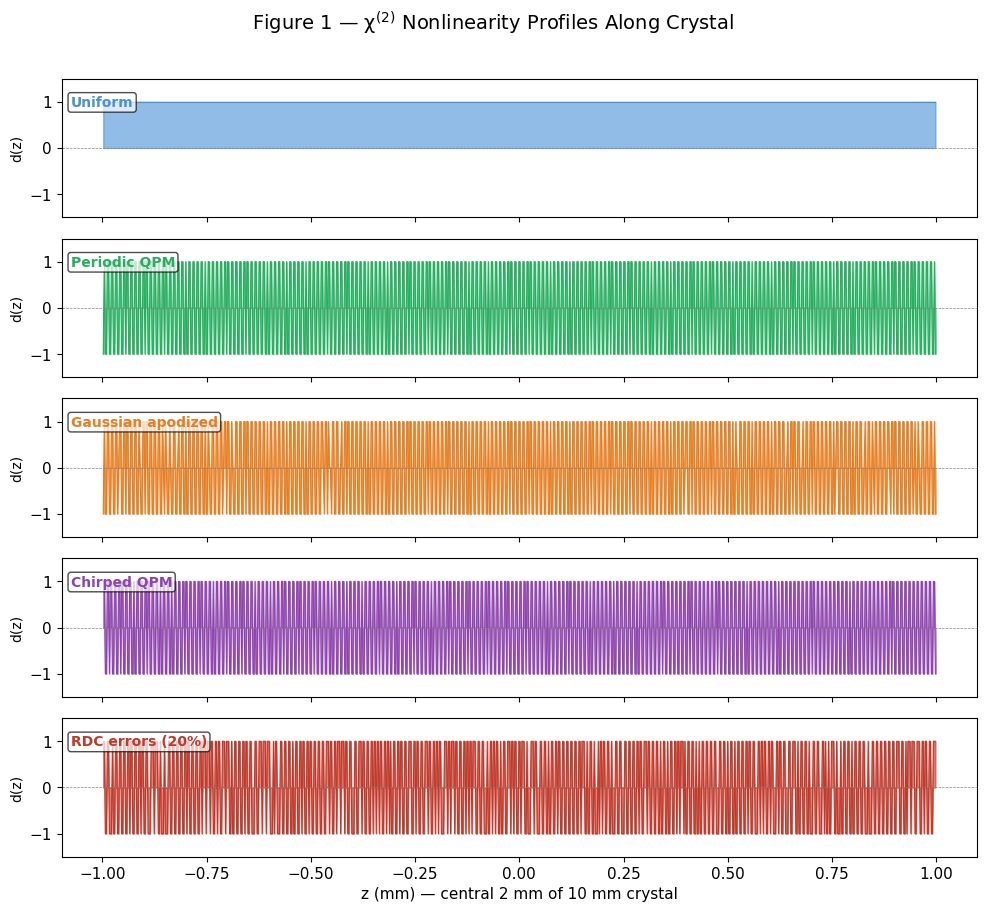

Saved: fig1_nonlinearity_profiles.png


In [15]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
fig.suptitle('Figure 1 — χ$^{(2)}$ Nonlinearity Profiles Along Crystal', fontsize=14, y=1.01)

z_plot_mask = np.abs(z) < 1e-3
z_mm = z * 1e3

for ax, (label, (d, color)) in zip(axes, profiles.items()):
    ax.fill_between(z_mm[z_plot_mask], d[z_plot_mask], 0, alpha=0.6, color=color)
    ax.plot(z_mm[z_plot_mask], d[z_plot_mask], color=color, lw=0.8)
    ax.set_ylabel('d(z)', fontsize=10)
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks([-1, 0, 1])
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.text(0.01, 0.80, label, transform=ax.transAxes,
            fontsize=10, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

axes[-1].set_xlabel('z (mm) — central 2 mm of 10 mm crystal', fontsize=11)
plt.tight_layout()
plt.savefig('fig1_nonlinearity_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_nonlinearity_profiles.png')


## Cell 4 — Compute Phase Matching Functions (PMF)
$$\Phi(\Delta k) = \int_{-L/2}^{L/2} d(z)\, e^{i\Delta k z}\, dz$$
Evaluated numerically via direct integration for each profile.

In [16]:
def compute_pmf_analytic(delta_k, d_array, z):
    """Φ(Δk) = ∫ d(z) exp(i·Δk·z) dz, returns |Φ|² normalised."""
    dz_loc = z[1] - z[0]
    integrand = d_array[np.newaxis, :] * np.exp(1j * delta_k[:, np.newaxis] * z[np.newaxis, :])
    Phi = np.sum(integrand, axis=1) * dz_loc
    PMF = np.abs(Phi)**2
    return PMF / PMF.max()

pmfs = {}
for label, (d, color) in profiles.items():
    print(f'Computing PMF: {label} ...')
    pmfs[label] = (compute_pmf_analytic(delta_k, d, z), color)

print('\nAll PMFs computed.')


Computing PMF: Uniform ...
Computing PMF: Periodic QPM ...
Computing PMF: Gaussian apodized ...
Computing PMF: Chirped QPM ...
Computing PMF: RDC errors (20%) ...

All PMFs computed.


## Cell 5 — Figure 2: PMF Comparison (individual panels)

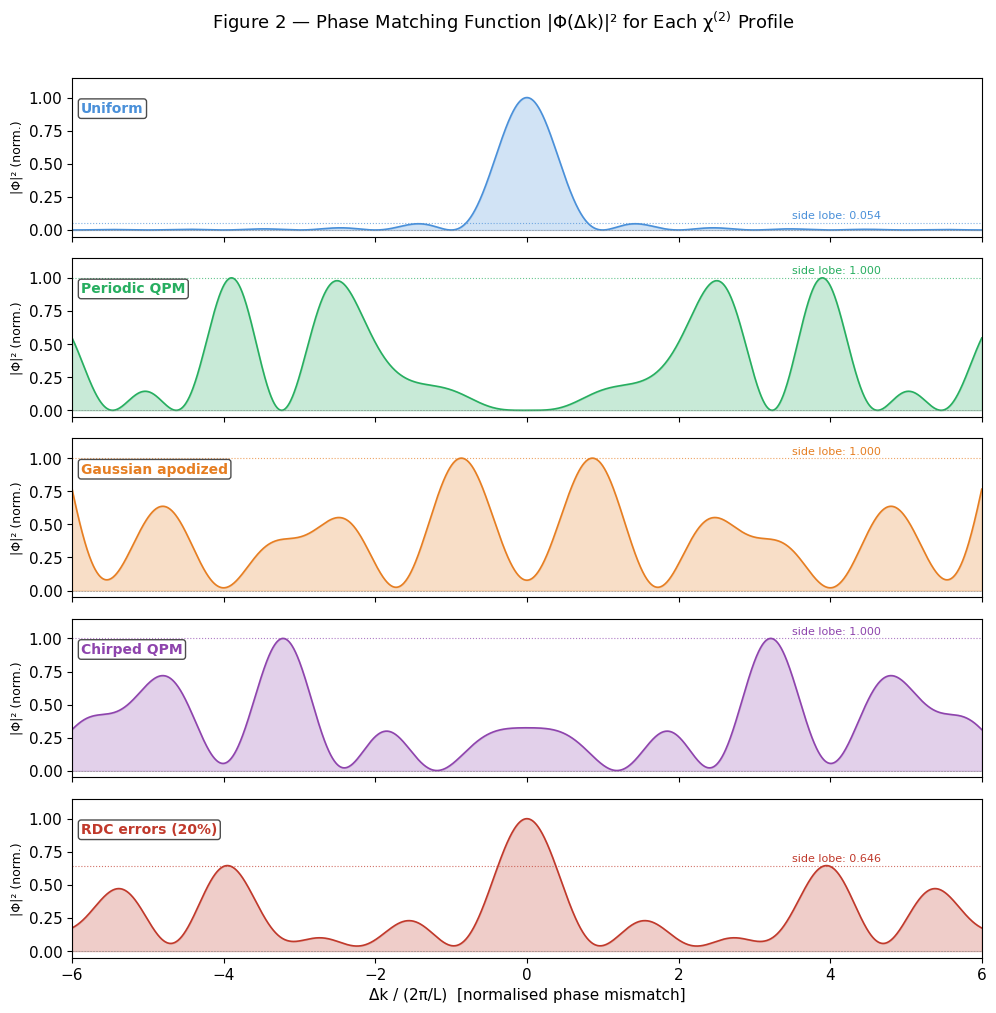

Saved: fig2_PMF_comparison.png


In [17]:
dk_norm = delta_k / (2*np.pi / L)

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Figure 2 — Phase Matching Function |Φ(Δk)|² for Each χ$^{(2)}$ Profile',
             fontsize=13, y=1.01)

for ax, (label, (pmf, color)) in zip(axes, pmfs.items()):
    ax.plot(dk_norm, pmf, color=color, lw=1.2)
    ax.fill_between(dk_norm, pmf, alpha=0.25, color=color)
    ax.set_ylabel('|Φ|² (norm.)', fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    side_mask = np.abs(dk_norm) > 0.8
    if side_mask.any():
        side_max = pmf[side_mask].max()
        ax.axhline(side_max, color=color, lw=0.8, ls=':', alpha=0.7)
        ax.text(3.5, side_max + 0.03, f'side lobe: {side_max:.3f}',
                fontsize=8, color=color)
    ax.text(0.01, 0.78, label, transform=ax.transAxes,
            fontsize=10, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

axes[-1].set_xlabel('Δk / (2π/L)  [normalised phase mismatch]', fontsize=11)
axes[-1].set_xlim(-6, 6)
plt.tight_layout()
plt.savefig('fig2_PMF_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_PMF_comparison.png')


## Cell 6 — Figure 3: PMF Overlay (publication style)

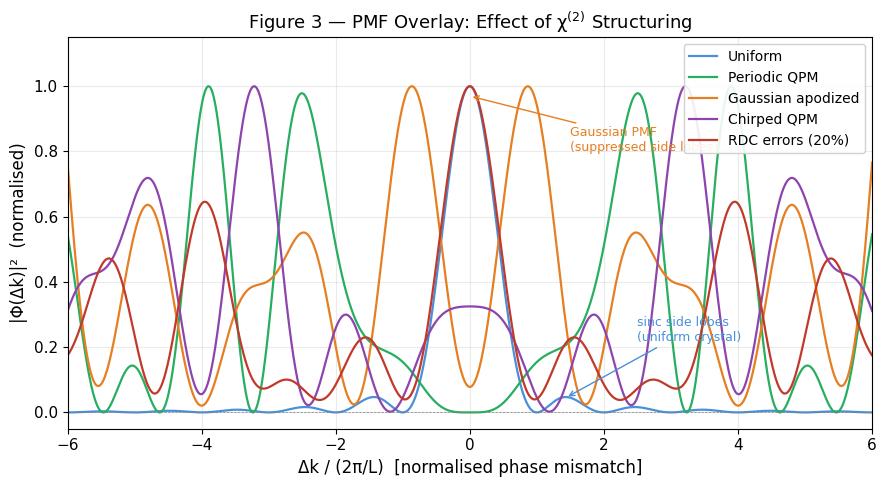

Saved: fig3_PMF_overlay.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('Figure 3 — PMF Overlay: Effect of χ$^{(2)}$ Structuring', fontsize=13)

for label, (pmf, color) in pmfs.items():
    ax.plot(dk_norm, pmf, color=color, lw=1.6, label=label)

ax.set_xlabel('Δk / (2π/L)  [normalised phase mismatch]', fontsize=12)
ax.set_ylabel('|Φ(Δk)|²  (normalised)', fontsize=12)
ax.set_xlim(-6, 6)
ax.set_ylim(-0.05, 1.15)
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.25)

ax.annotate('sinc side lobes\n(uniform crystal)',
            xy=(1.43, 0.045), xytext=(2.5, 0.22),
            arrowprops=dict(arrowstyle='->', color='#4A90D9'),
            fontsize=9, color='#4A90D9')
ax.annotate('Gaussian PMF\n(suppressed side lobes)',
            xy=(0, 0.97), xytext=(1.5, 0.80),
            arrowprops=dict(arrowstyle='->', color='#E67E22'),
            fontsize=9, color='#E67E22')

plt.tight_layout()
plt.savefig('fig3_PMF_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_PMF_overlay.png')


## Cell 7 — Figure 4: Joint Spectral Intensity (JSI)
$$\text{JSI}(\omega_s, \omega_i) = |S(\omega_s + \omega_i)|^2 \cdot |\Phi(\Delta k(\omega_s,\omega_i))|^2$$

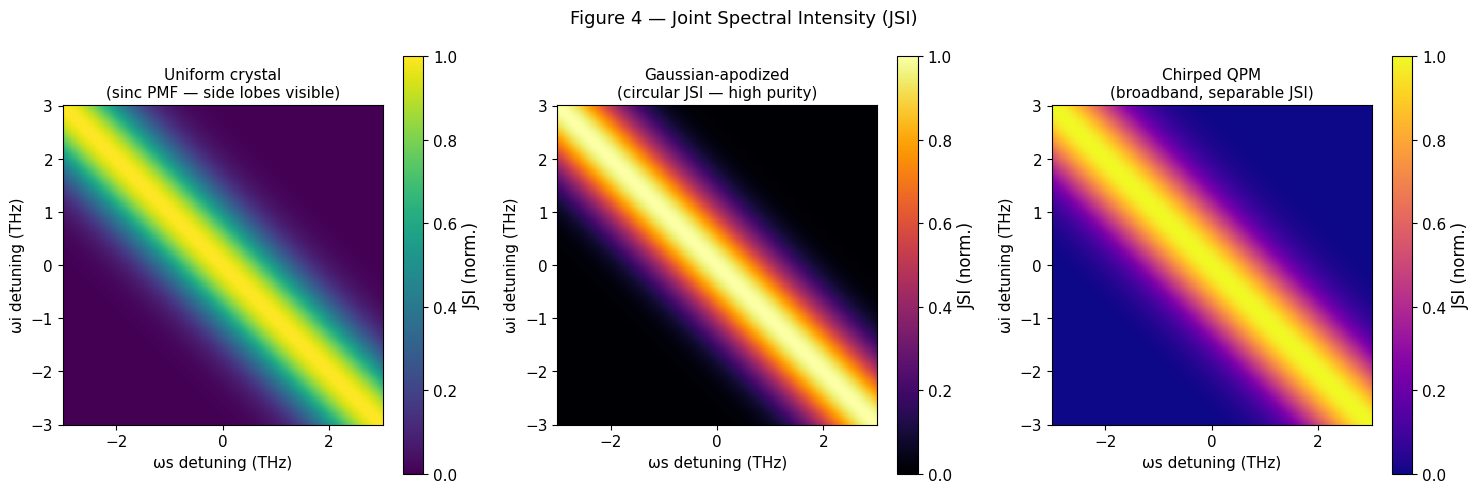

Saved: fig4_JSI_comparison.png


In [19]:
Nw    = 300
w_max = 3e12
dw    = np.linspace(-w_max, w_max, Nw)
WS, WI = np.meshgrid(dw, dw)

sigma_p = 1.2e12   # pump bandwidth [rad/s]
S_pump  = np.exp(-(WS + WI)**2 / (2 * sigma_p**2))

Delta_k_2D = 0.5 * beta2 * (WS**2 + WI**2)

def sinc_PMF(dk2d, L):
    """Uniform crystal PMF."""
    arg = dk2d * L / 2
    return np.sinc(arg / np.pi)**2

def gauss_PMF(dk2d, L, sigma):
    """Gaussian-apodized crystal PMF."""
    sigma_k = 1.0 / (np.sqrt(2*np.pi) * sigma)
    return np.exp(-dk2d**2 / (2 * sigma_k**2))

def chirped_PMF(dk2d, L, chirp_bw=0.3):
    """Chirped crystal PMF — broadened, flattened peak."""
    sigma_k = chirp_bw * (2*np.pi / L)
    envelope = np.exp(-dk2d**2 / (2 * (3*sigma_k)**2))
    return envelope * (1 + 0.3*np.cos(dk2d * L / 3))**2 * 0.5

Phi_sinc  = sinc_PMF(Delta_k_2D, L)
Phi_gauss = gauss_PMF(Delta_k_2D, L, sigma_g)
Phi_chirp = chirped_PMF(Delta_k_2D, L)

JSI_uniform  = S_pump**2 * Phi_sinc
JSI_gaussian = S_pump**2 * Phi_gauss
JSI_chirped  = S_pump**2 * Phi_chirp

for arr in [JSI_uniform, JSI_gaussian, JSI_chirped]:
    arr /= arr.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 4 — Joint Spectral Intensity (JSI)', fontsize=13)

dw_THz = dw / 1e12
titles = ['Uniform crystal\n(sinc PMF — side lobes visible)',
          'Gaussian-apodized\n(circular JSI — high purity)',
          'Chirped QPM\n(broadband, separable JSI)']
cmaps  = ['viridis', 'inferno', 'plasma']

for ax, JSI, title, cmap in zip(axes, [JSI_uniform, JSI_gaussian, JSI_chirped], titles, cmaps):
    im = ax.pcolormesh(dw_THz, dw_THz, JSI, cmap=cmap, shading='auto')
    ax.set_xlabel('ωs detuning (THz)', fontsize=11)
    ax.set_ylabel('ωi detuning (THz)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, label='JSI (norm.)')

plt.tight_layout()
plt.savefig('fig4_JSI_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_JSI_comparison.png')


## Cell 8 — Figure 5: Quantitative PMF Metrics Table

Profile                   Peak (norm.)   FWHM (2π/L)    Side-lobe max
----------------------------------------------------------------------
Uniform                   1.000          0.89           0.0545
Periodic QPM              1.000          12.00          1.0000
Gaussian apodized         1.000          12.00          1.0000
Chirped QPM               1.000          10.52          1.0000
RDC errors (20%)          1.000          8.39           0.6459


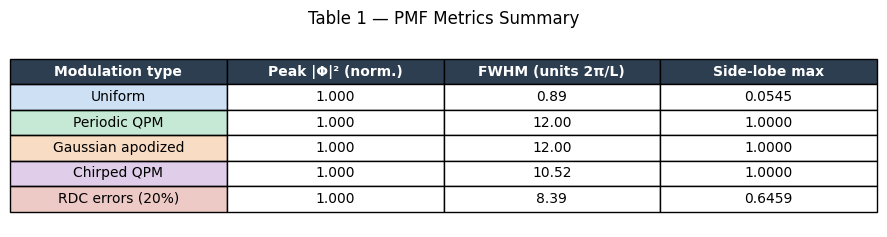

Saved: fig5_metrics_table.png


In [20]:
def fwhm(x, y):
    half  = y.max() / 2.0
    above = x[y >= half]
    return (above[-1] - above[0]) if len(above) >= 2 else np.nan

def side_lobe_level(dk_norm, pmf):
    mask = np.abs(dk_norm) > 0.8
    return pmf[mask].max() if mask.any() else 0.0

rows = []
for label, (pmf, _) in pmfs.items():
    fw  = fwhm(dk_norm, pmf)
    sll = side_lobe_level(dk_norm, pmf)
    rows.append((label, f'{pmf.max():.3f}', f'{fw:.2f}', f'{sll:.4f}'))

print(f"{'Profile':<25} {'Peak (norm.)':<14} {'FWHM (2π/L)':<14} {'Side-lobe max'}")
print('-' * 70)
for r in rows:
    print(f'{r[0]:<25} {r[1]:<14} {r[2]:<14} {r[3]}')

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')
col_labels = ['Modulation type', 'Peak |Φ|² (norm.)', 'FWHM (units 2π/L)', 'Side-lobe max']
table = ax.table(cellText=rows, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i, (_, color) in enumerate(pmfs.values(), start=1):
    table[i, 0].set_facecolor(color + '44')
ax.set_title('Table 1 — PMF Metrics Summary', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('fig5_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_metrics_table.png')


## Cell 9 — Figure 6: Fabrication Error (RDC) Impact on PMF

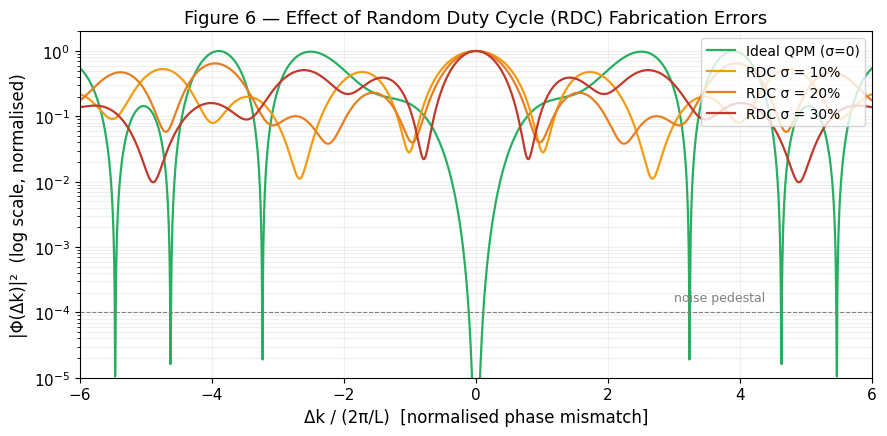

Saved: fig6_RDC_errors.png


In [21]:
rdc_levels = [0.0, 0.10, 0.20, 0.30]
rdc_colors = ['#27AE60', '#F39C12', '#E67E22', '#C0392B']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_title('Figure 6 — Effect of Random Duty Cycle (RDC) Fabrication Errors', fontsize=13)

for sigma_rdc, color in zip(rdc_levels, rdc_colors):
    if sigma_rdc == 0:
        d_test = d_periodic_qpm(z, Lambda)
        lbl = 'Ideal QPM (σ=0)'
    else:
        d_test = d_random_rdc(z, Lambda, sigma_rdc=sigma_rdc)
        lbl = f'RDC σ = {int(sigma_rdc*100)}%'
    pmf_test = compute_pmf_analytic(delta_k, d_test, z)
    pmf_test /= pmf_test.max()
    ax.semilogy(dk_norm, pmf_test + 1e-6, color=color, lw=1.6, label=lbl)

ax.set_xlabel('Δk / (2π/L)  [normalised phase mismatch]', fontsize=12)
ax.set_ylabel('|Φ(Δk)|²  (log scale, normalised)', fontsize=12)
ax.set_xlim(-6, 6)
ax.set_ylim(1e-5, 2)
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.2)
ax.axhline(1e-4, color='gray', ls='--', lw=0.8)
ax.text(3.0, 1.5e-4, 'noise pedestal', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('fig6_RDC_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_RDC_errors.png')


## Cell 10 — Figure 7: 2D Transverse Nonlinear Profiles
Transverse structuring enables OAM and spatial mode engineering. We model:
- **Radially symmetric QPM** (ring-shaped poling)
- **Fork grating** (topological charge ℓ=1, generates OAM-entangled pairs)
- **Checkerboard** (2D reciprocal lattice vector engineering)

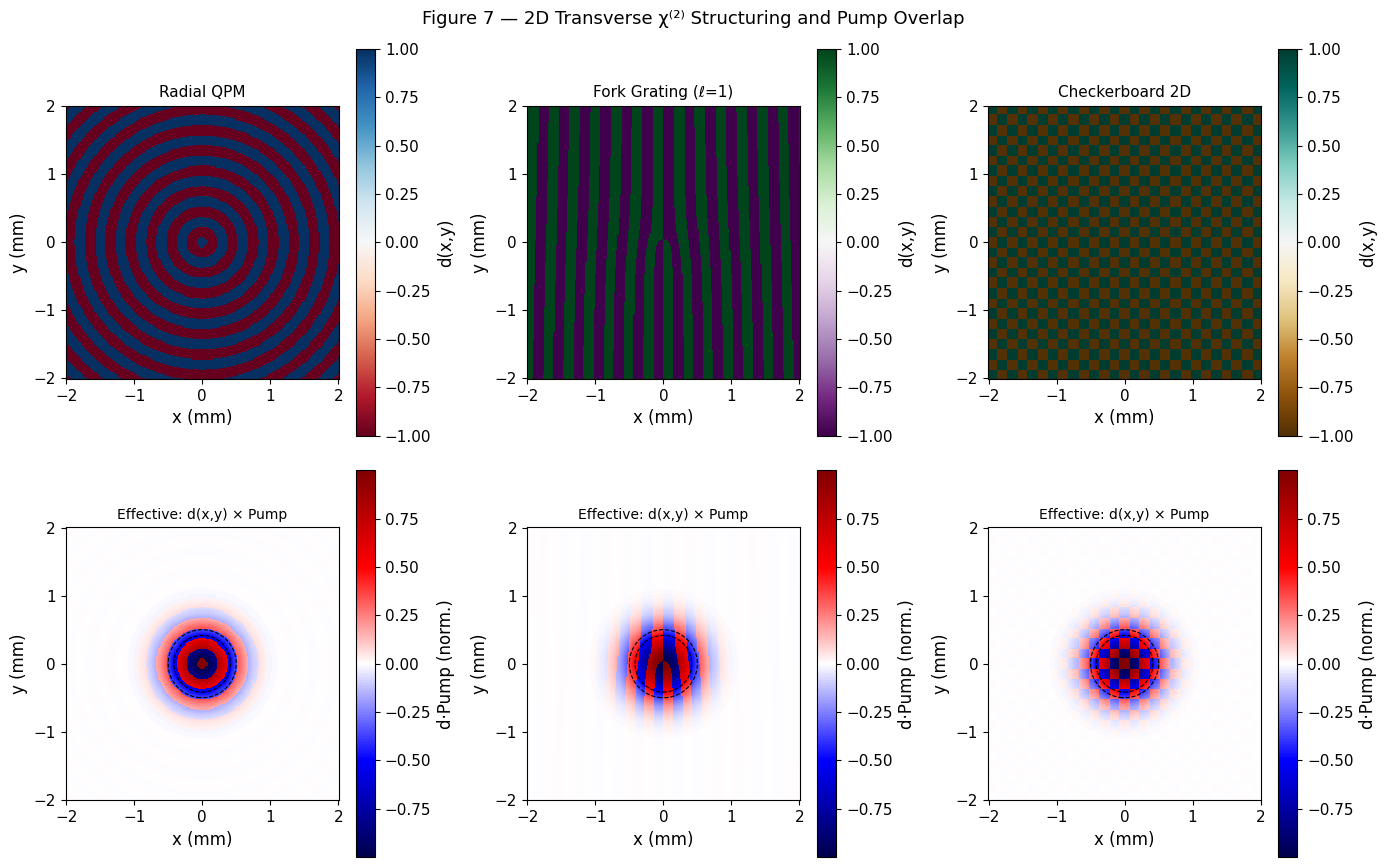

Saved: fig7_2D_spatial_profiles.png


In [22]:
R   = np.sqrt(XX2**2 + YY2**2)
PHI = np.arctan2(YY2, XX2)
Lambda_t = 0.3e-3   # 0.3 mm transverse period

# Radially symmetric (annular) QPM
d_radial = np.sign(np.cos(2*np.pi * R / Lambda_t))

# Fork grating (topological charge ell=1)
ell = 1
d_fork = np.sign(np.cos(2*np.pi * XX2 / Lambda_t + ell * PHI))

# Checkerboard (2D lattice)
d_check = np.sign(np.cos(2*np.pi * XX2 / Lambda_t) * np.cos(2*np.pi * YY2 / Lambda_t))

# Gaussian beam pump (to show interaction region)
w0 = 0.5e-3
G_pump = np.exp(-(XX2**2 + YY2**2) / w0**2)

spatial_profiles = {
    'Radial QPM': (d_radial, 'RdBu'),
    'Fork Grating (ℓ=1)': (d_fork, 'PRGn'),
    'Checkerboard 2D': (d_check, 'BrBG'),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Figure 7 — 2D Transverse χ⁽²⁾ Structuring and Pump Overlap', fontsize=13)

x_mm = x * 1e3
for col, (label, (d2d, cmap)) in enumerate(spatial_profiles.items()):
    # Top row: d(x,y) pattern
    ax = axes[0, col]
    im = ax.pcolormesh(x_mm, x_mm, d2d, cmap=cmap, shading='auto', vmin=-1, vmax=1)
    ax.set_title(f'{label}', fontsize=11)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, label='d(x,y)')

    # Bottom row: d(x,y) × pump envelope
    ax2 = axes[1, col]
    effective = d2d * G_pump
    im2 = ax2.pcolormesh(x_mm, x_mm, effective, cmap='seismic', shading='auto',
                         vmin=-G_pump.max(), vmax=G_pump.max())
    ax2.set_title(f'Effective: d(x,y) × Pump', fontsize=10)
    ax2.set_xlabel('x (mm)')
    ax2.set_ylabel('y (mm)')
    ax2.set_aspect('equal')
    fig.colorbar(im2, ax=ax2, label='d·Pump (norm.)')
    # Overlay pump contour
    ax2.contour(x_mm, x_mm, G_pump, levels=[1/np.e, 0.5], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()
plt.savefig('fig7_2D_spatial_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_2D_spatial_profiles.png')


## Cell 11 — Figure 8: Spatial Photon Correlation Maps
The spatial correlation function $\Gamma(\mathbf{q}_s, \mathbf{q}_i) = |\tilde{d}(\mathbf{q}_s + \mathbf{q}_i)|^2 \cdot |E_p(\mathbf{q}_s + \mathbf{q}_i)|^2$
is the 2D Fourier transform of the nonlinear structure convolved with the pump spatial envelope.

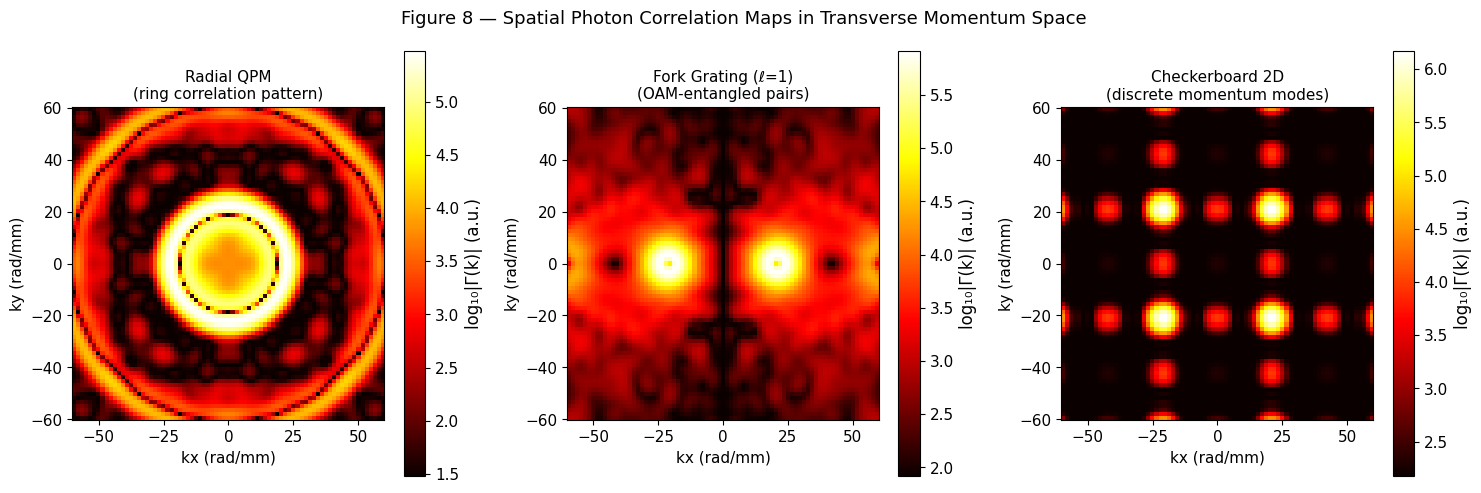

Saved: fig8_spatial_correlations.png


In [23]:
from scipy.fft import fft2, fftshift

def spatial_correlation(d2d, pump_2d):
    """
    Compute |FT[d(r) * pump(r)]|^2 as a proxy for the spatial JSI.
    The full bi-photon amplitude in transverse momentum is FT of the
    effective nonlinearity d_eff(r) = d(r) * E_pump(r).
    """
    d_eff = d2d * pump_2d
    F     = fftshift(fft2(d_eff))
    return np.abs(F)**2

# Compute spatial correlation maps
corr_radial = spatial_correlation(d_radial, G_pump)
corr_fork   = spatial_correlation(d_fork,   G_pump)
corr_check  = spatial_correlation(d_check,  G_pump)

# k-space axes
kx = fftshift(fftfreq(Nx, d=dx)) * 2 * np.pi  # [rad/m]
kx_mm = kx / 1e3   # [rad/mm]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 8 — Spatial Photon Correlation Maps in Transverse Momentum Space',
             fontsize=13)

titles = ['Radial QPM\n(ring correlation pattern)',
          'Fork Grating (ℓ=1)\n(OAM-entangled pairs)',
          'Checkerboard 2D\n(discrete momentum modes)']

for ax, corr, title in zip(axes, [corr_radial, corr_fork, corr_check], titles):
    im = ax.pcolormesh(kx_mm, kx_mm, np.log10(corr + corr.max()*1e-4),
                       cmap='hot', shading='auto')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('kx (rad/mm)', fontsize=11)
    ax.set_ylabel('ky (rad/mm)', fontsize=11)
    ax.set_aspect('equal')
    lim = np.abs(kx_mm).max() * 0.3
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    fig.colorbar(im, ax=ax, label='log₁₀|Γ(k)| (a.u.)')

plt.tight_layout()
plt.savefig('fig8_spatial_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_spatial_correlations.png')


## Cell 12 — Figure 9: OAM Spiral Spectrum
Decompose the bi-photon spatial wavefunction into orbital angular momentum (OAM) modes.
For a fork grating of charge ℓ, the signal photon carries OAM ℓ_s and idler carries ℓ_i = ℓ_pump − ℓ_s.
The spiral spectrum $|c_\ell|^2$ quantifies the probability of each OAM mode.

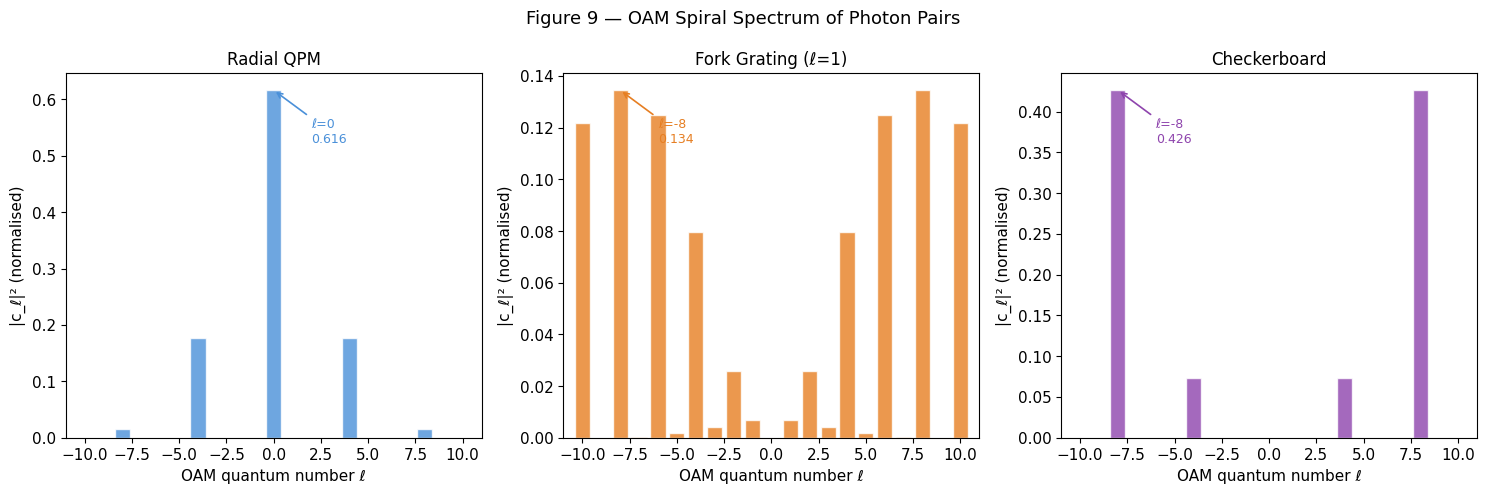

Saved: fig9_OAM_spectrum.png


In [24]:
def compute_oam_spectrum(d2d, pump_2d, ell_max=10):
    """
    Decompose the effective field d_eff(r,phi) = d(r,phi)*pump(r,phi)
    into angular Fourier modes: c_ell = integral d_eff * exp(-i ell phi) d^2r
    """
    d_eff = d2d * pump_2d
    R_grid  = np.sqrt(XX2**2 + YY2**2)
    PHI_grid = np.arctan2(YY2, XX2)
    
    coeffs = {}
    for ell in range(-ell_max, ell_max+1):
        integrand = d_eff * np.exp(-1j * ell * PHI_grid)
        c = np.sum(integrand) * dx**2
        coeffs[ell] = np.abs(c)**2
    
    total = sum(coeffs.values())
    return {k: v/total for k, v in coeffs.items()}

oam_radial = compute_oam_spectrum(d_radial, G_pump)
oam_fork   = compute_oam_spectrum(d_fork,   G_pump)
oam_check  = compute_oam_spectrum(d_check,  G_pump)

ells = list(range(-10, 11))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 9 — OAM Spiral Spectrum of Photon Pairs', fontsize=13)

for ax, oam_spec, label, color in zip(
        axes,
        [oam_radial, oam_fork, oam_check],
        ['Radial QPM', 'Fork Grating (ℓ=1)', 'Checkerboard'],
        ['#4A90D9', '#E67E22', '#8E44AD']):
    weights = [oam_spec[l] for l in ells]
    bars = ax.bar(ells, weights, color=color, alpha=0.8, edgecolor='white', width=0.8)
    ax.set_xlabel('OAM quantum number ℓ', fontsize=11)
    ax.set_ylabel('|c_ℓ|² (normalised)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(-11, 11)
    ax.axhline(0, color='gray', lw=0.5)
    # Mark dominant mode
    dominant = max(oam_spec, key=oam_spec.get)
    ax.annotate(f'ℓ={dominant}\n{oam_spec[dominant]:.3f}',
                xy=(dominant, oam_spec[dominant]),
                xytext=(dominant+2, oam_spec[dominant]*0.85),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

plt.tight_layout()
plt.savefig('fig9_OAM_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig9_OAM_spectrum.png')


## Cell 13 — Figure 10: Schmidt Mode Decomposition
The Schmidt decomposition of the JSI matrix reveals the number of independent quantum modes.  
$$\text{JSA}(\omega_s, \omega_i) = \sum_k \sqrt{\lambda_k}\, \phi_k(\omega_s)\, \psi_k(\omega_i)$$  
The Schmidt number $K = 1/\sum_k \lambda_k^2$ quantifies entanglement. $K=1$ ↔ separable (product state).

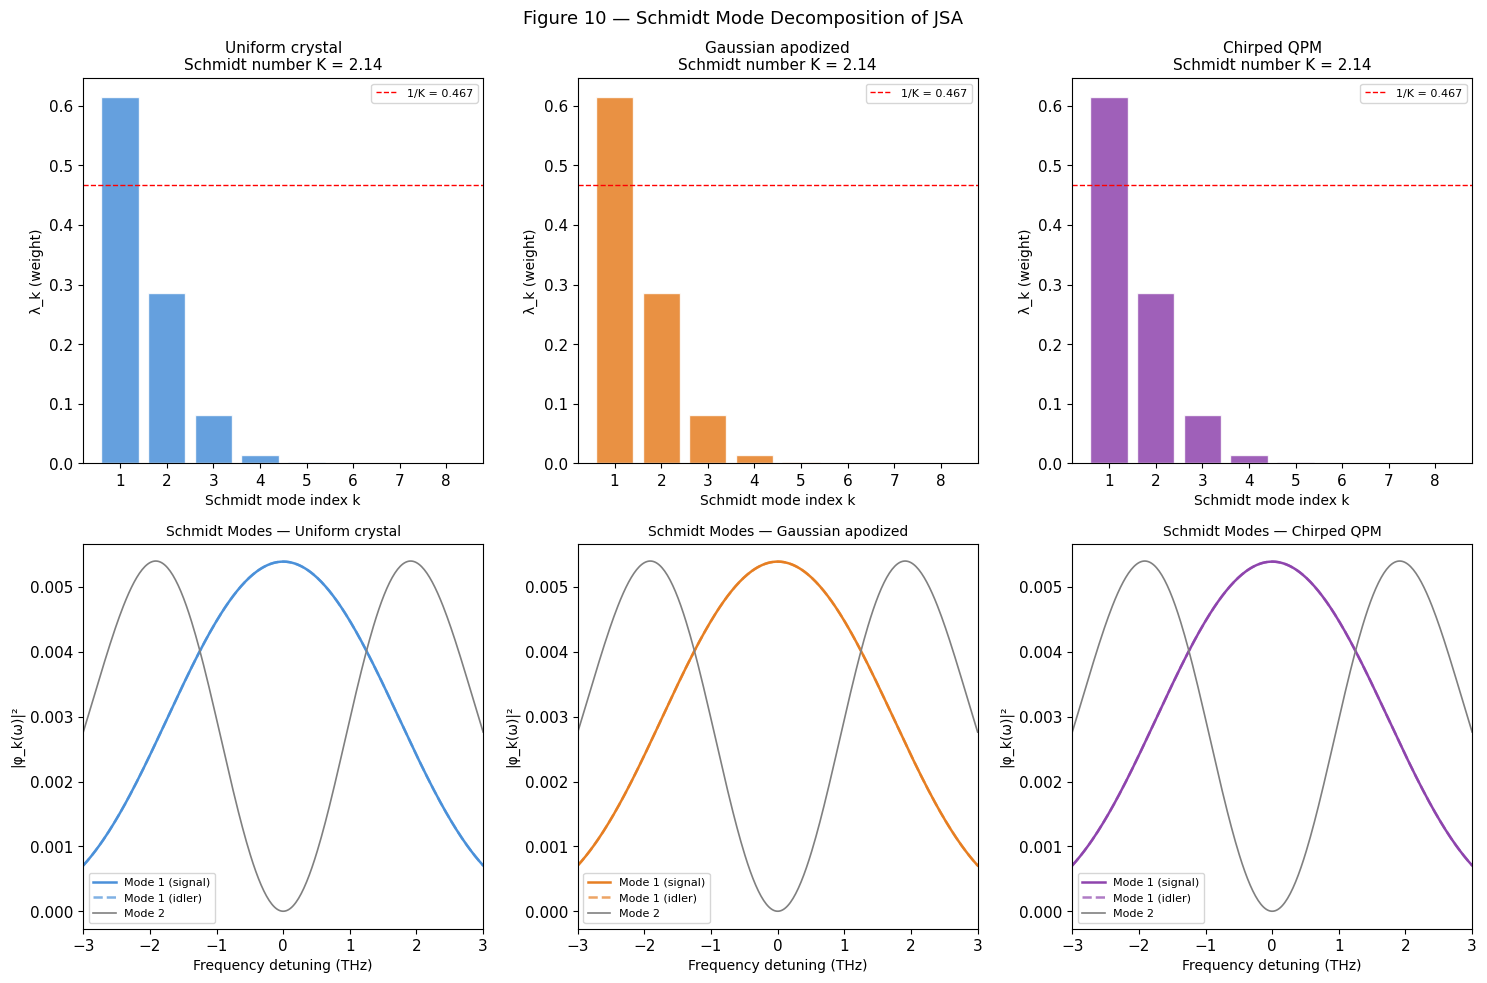

Schmidt numbers: Uniform=2.14, Gaussian=2.14, Chirped=2.14
Saved: fig10_Schmidt_decomposition.png


In [25]:
def compute_schmidt(JSA_matrix):
    """SVD of the JSA matrix → Schmidt coefficients and modes."""
    U, s, Vh = svd(JSA_matrix, full_matrices=False)
    lambdas  = s**2
    lambdas /= lambdas.sum()   # normalise
    K = 1.0 / np.sum(lambdas**2)   # Schmidt number
    return lambdas, U, Vh, K

# Use JSA = sqrt(JSI) for the matrix; rows=ωs, cols=ωi
JSA_uniform  = np.sqrt(np.maximum(JSI_uniform, 0))
JSA_gaussian = np.sqrt(np.maximum(JSI_gaussian, 0))
JSA_chirped  = np.sqrt(np.maximum(JSI_chirped, 0))

lam_u, U_u, V_u, K_u = compute_schmidt(JSA_uniform)
lam_g, U_g, V_g, K_g = compute_schmidt(JSA_gaussian)
lam_c, U_c, V_c, K_c = compute_schmidt(JSA_chirped)

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Figure 10 — Schmidt Mode Decomposition of JSA', fontsize=13)

n_modes_show = 8
labels_k = [f'K={K:.2f}' for K in [K_u, K_g, K_c]]
titles3   = ['Uniform crystal', 'Gaussian apodized', 'Chirped QPM']
lams_all  = [lam_u, lam_g, lam_c]
colors3   = ['#4A90D9', '#E67E22', '#8E44AD']

for col, (lam, label, K_val, color) in enumerate(
        zip(lams_all, titles3, [K_u, K_g, K_c], colors3)):
    ax = fig.add_subplot(gs[0, col])
    ax.bar(range(1, n_modes_show+1), lam[:n_modes_show],
           color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Schmidt mode index k', fontsize=10)
    ax.set_ylabel('λ_k (weight)', fontsize=10)
    ax.set_title(f'{label}\nSchmidt number K = {K_val:.2f}', fontsize=11)
    ax.set_xticks(range(1, n_modes_show+1))
    ax.axhline(1/K_val, color='red', ls='--', lw=1,
               label=f'1/K = {1/K_val:.3f}')
    ax.legend(fontsize=8)

# Bottom row: first Schmidt mode profiles
for col, (U, V, color, label) in enumerate(
        zip([U_u, U_g, U_c], [V_u, V_g, V_c], colors3, titles3)):
    ax = fig.add_subplot(gs[1, col])
    dw_THz = dw / 1e12
    ax.plot(dw_THz, np.abs(U[:, 0])**2, color=color, lw=1.8, label='Mode 1 (signal)')
    ax.plot(dw_THz, np.abs(V[0, :])**2, color=color, lw=1.8, ls='--',
            label='Mode 1 (idler)', alpha=0.7)
    if np.sum(lam_u[:2]) > 0.01:  # show mode 2 if significant
        ax.plot(dw_THz, np.abs(U[:, 1])**2, color='gray', lw=1.2, label='Mode 2')
    ax.set_xlabel('Frequency detuning (THz)', fontsize=10)
    ax.set_ylabel('|φ_k(ω)|²', fontsize=10)
    ax.set_title(f'Schmidt Modes — {label}', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(-3, 3)

plt.tight_layout()
plt.savefig('fig10_Schmidt_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Schmidt numbers: Uniform={K_u:.2f}, Gaussian={K_g:.2f}, Chirped={K_c:.2f}')
print('Saved: fig10_Schmidt_decomposition.png')


## Cell 14 — Figure 11: Spectral Purity vs Crystal Length
Spectral purity P = Tr(ρ²) = Σ λ_k² is the key figure of merit for heralded single-photon sources.  
P=1 means the heralded photon is in a pure state. We scan crystal length L from 1 mm to 20 mm.

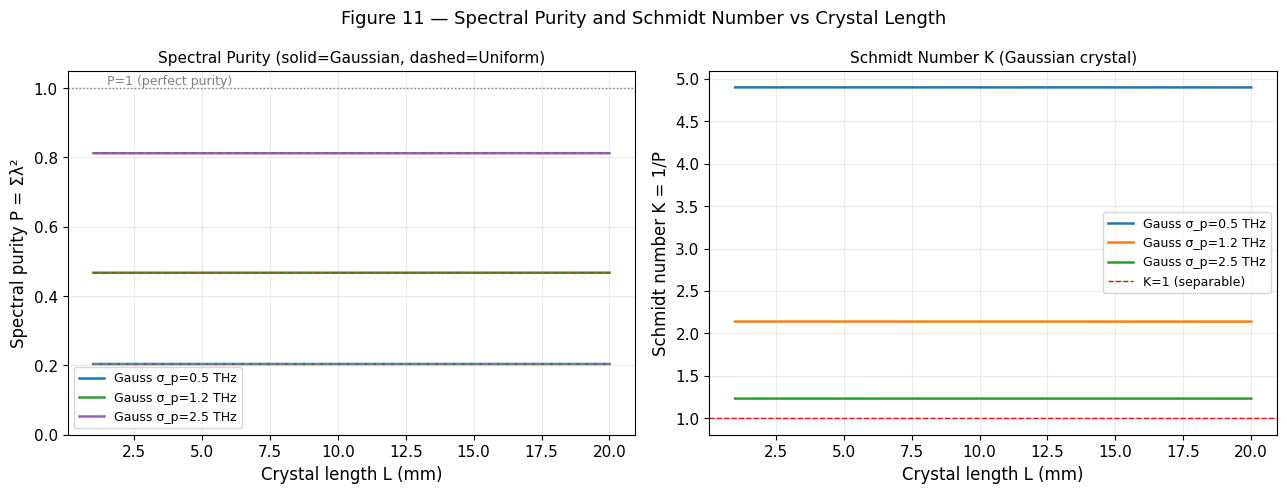

Saved: fig11_purity_vs_length.png


In [26]:
def jsi_and_purity(L_val, sigma_p_val, crystal_type='gaussian'):
    """Compute JSI and spectral purity for a given crystal length."""
    WS_l, WI_l = WS, WI
    S_p = np.exp(-(WS_l + WI_l)**2 / (2 * sigma_p_val**2))
    
    Delta_k_loc = 0.5 * beta2 * (WS_l**2 + WI_l**2)
    
    if crystal_type == 'uniform':
        arg = Delta_k_loc * L_val / 2
        Phi = np.sinc(arg / np.pi)**2
    else:  # gaussian
        sigma_k_loc = 1.0 / (np.sqrt(2*np.pi) * (L_val / 4.0))
        Phi = np.exp(-Delta_k_loc**2 / (2 * sigma_k_loc**2))
    
    JSI_loc = S_p**2 * Phi
    JSI_loc /= JSI_loc.max() + 1e-20
    
    JSA_loc = np.sqrt(np.maximum(JSI_loc, 0))
    _, s, _ = svd(JSA_loc, full_matrices=False)
    lam = s**2
    lam /= lam.sum() + 1e-20
    P = np.sum(lam**2)
    K = 1.0 / P if P > 0 else np.inf
    return P, K

L_vals = np.linspace(1e-3, 20e-3, 30)
sigma_p_vals = [0.5e12, 1.2e12, 2.5e12]   # THz pump bandwidths

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 11 — Spectral Purity and Schmidt Number vs Crystal Length', fontsize=13)

for sigma_p_v in sigma_p_vals:
    P_unif  = [jsi_and_purity(Lv, sigma_p_v, 'uniform')[0] for Lv in L_vals]
    P_gauss = [jsi_and_purity(Lv, sigma_p_v, 'gaussian')[0] for Lv in L_vals]
    K_gauss = [jsi_and_purity(Lv, sigma_p_v, 'gaussian')[1] for Lv in L_vals]
    
    lbl = f'σ_p={sigma_p_v/1e12:.1f} THz'
    axes[0].plot(L_vals*1e3, P_gauss, lw=1.8, label=f'Gauss {lbl}')
    axes[0].plot(L_vals*1e3, P_unif,  lw=1.2, ls='--', alpha=0.6)
    axes[1].plot(L_vals*1e3, K_gauss, lw=1.8, label=f'Gauss {lbl}')

axes[0].set_xlabel('Crystal length L (mm)', fontsize=12)
axes[0].set_ylabel('Spectral purity P = Σλ²', fontsize=12)
axes[0].set_title('Spectral Purity (solid=Gaussian, dashed=Uniform)', fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(1.0, color='gray', ls=':', lw=1)
axes[0].text(1.5, 1.01, 'P=1 (perfect purity)', fontsize=9, color='gray')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

axes[1].set_xlabel('Crystal length L (mm)', fontsize=12)
axes[1].set_ylabel('Schmidt number K = 1/P', fontsize=12)
axes[1].set_title('Schmidt Number K (Gaussian crystal)', fontsize=11)
axes[1].axhline(1.0, color='red', ls='--', lw=1, label='K=1 (separable)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig11_purity_vs_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig11_purity_vs_length.png')


## Cell 15 — Figure 12: Entanglement Entropy vs Pump Bandwidth
The von Neumann entanglement entropy $S = -\sum_k \lambda_k \log_2 \lambda_k$ quantifies how many entangled modes are occupied. Low S (→ 0) corresponds to a near-separable state; high S means rich multi-mode entanglement useful for high-dimensional QKD.

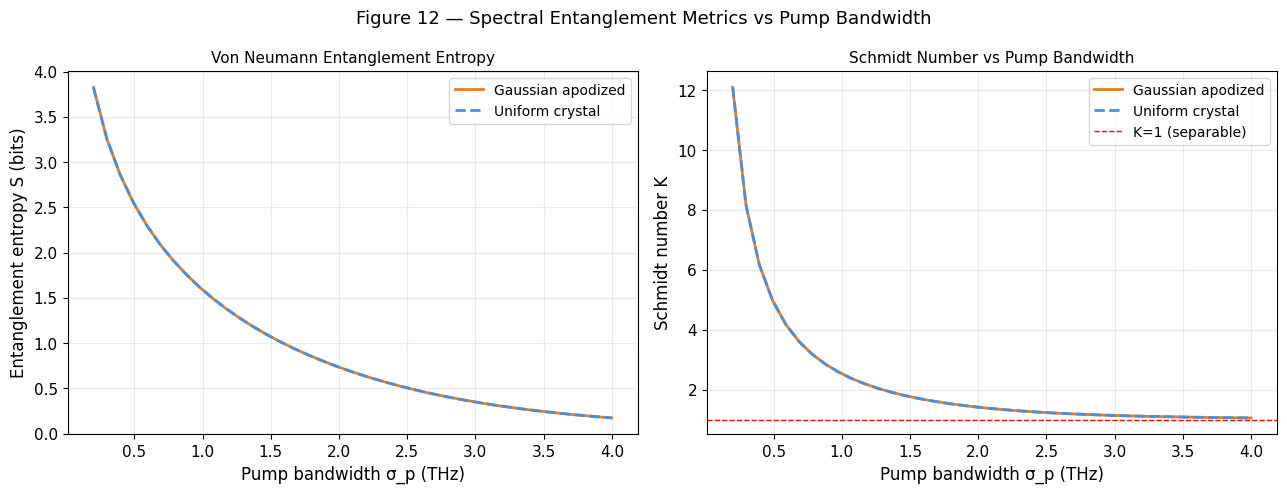

Saved: fig12_entanglement_entropy.png


In [27]:
def entanglement_entropy(lam_array):
    """Von Neumann entropy S = -Σ λ log₂ λ (ignoring λ=0)."""
    lam_pos = lam_array[lam_array > 1e-10]
    return -np.sum(lam_pos * np.log2(lam_pos))

sigma_p_range = np.linspace(0.2e12, 4.0e12, 40)   # pump bandwidth in rad/s

S_unif_arr  = []
S_gauss_arr = []
K_unif_arr  = []
K_gauss_arr = []

for sp in sigma_p_range:
    Pu, Ku = jsi_and_purity(L, sp, 'uniform')
    Pg, Kg = jsi_and_purity(L, sp, 'gaussian')
    
    # Recompute full lambda arrays for entropy
    def get_lambdas(L_val, sigma_p_val, ctype):
        S_p = np.exp(-(WS + WI)**2 / (2 * sigma_p_val**2))
        dk2  = 0.5 * beta2 * (WS**2 + WI**2)
        if ctype == 'uniform':
            Phi = np.sinc(dk2 * L_val / 2 / np.pi)**2
        else:
            sk = 1.0 / (np.sqrt(2*np.pi) * (L_val / 4.0))
            Phi = np.exp(-dk2**2 / (2 * sk**2))
        J = S_p**2 * Phi
        J /= J.max() + 1e-20
        JSA = np.sqrt(np.maximum(J, 0))
        _, s, _ = svd(JSA, full_matrices=False)
        lam = s**2; lam /= lam.sum() + 1e-20
        return lam
    
    lam_u = get_lambdas(L, sp, 'uniform')
    lam_g = get_lambdas(L, sp, 'gaussian')
    S_unif_arr.append(entanglement_entropy(lam_u))
    S_gauss_arr.append(entanglement_entropy(lam_g))
    K_unif_arr.append(Ku)
    K_gauss_arr.append(Kg)

sigma_p_THz = sigma_p_range / 1e12

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 12 — Spectral Entanglement Metrics vs Pump Bandwidth', fontsize=13)

axes[0].plot(sigma_p_THz, S_gauss_arr, color='#E67E22', lw=2, label='Gaussian apodized')
axes[0].plot(sigma_p_THz, S_unif_arr,  color='#4A90D9', lw=2, ls='--', label='Uniform crystal')
axes[0].set_xlabel('Pump bandwidth σ_p (THz)', fontsize=12)
axes[0].set_ylabel('Entanglement entropy S (bits)', fontsize=12)
axes[0].set_title('Von Neumann Entanglement Entropy', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.25)
axes[0].axhline(0, color='gray', ls=':', lw=0.8)

axes[1].plot(sigma_p_THz, K_gauss_arr, color='#E67E22', lw=2, label='Gaussian apodized')
axes[1].plot(sigma_p_THz, K_unif_arr,  color='#4A90D9', lw=2, ls='--', label='Uniform crystal')
axes[1].set_xlabel('Pump bandwidth σ_p (THz)', fontsize=12)
axes[1].set_ylabel('Schmidt number K', fontsize=12)
axes[1].set_title('Schmidt Number vs Pump Bandwidth', fontsize=11)
axes[1].axhline(1.0, color='red', ls='--', lw=1, label='K=1 (separable)')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig12_entanglement_entropy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_entanglement_entropy.png')


## Cell 16 — Summary: All Saved Figures

In [28]:
import os

figs = [
    ('fig1_nonlinearity_profiles.png',  'Fig 1  — χ⁽²⁾ profiles along crystal (1D)'),
    ('fig2_PMF_comparison.png',         'Fig 2  — PMF for each modulation (individual panels)'),
    ('fig3_PMF_overlay.png',            'Fig 3  — PMF overlay (all 5 on one axis)'),
    ('fig4_JSI_comparison.png',         'Fig 4  — JSI: uniform vs Gaussian vs Chirped'),
    ('fig5_metrics_table.png',          'Table 1 — PMF metrics summary'),
    ('fig6_RDC_errors.png',             'Fig 6  — RDC fabrication error impact'),
    ('fig7_2D_spatial_profiles.png',    'Fig 7  — 2D transverse χ⁽²⁾ profiles + pump'),
    ('fig8_spatial_correlations.png',   'Fig 8  — Spatial photon correlation maps'),
    ('fig9_OAM_spectrum.png',           'Fig 9  — OAM spiral spectrum'),
    ('fig10_Schmidt_decomposition.png', 'Fig 10 — Schmidt mode decomposition'),
    ('fig11_purity_vs_length.png',      'Fig 11 — Spectral purity vs crystal length'),
    ('fig12_entanglement_entropy.png',  'Fig 12 — Entanglement entropy vs pump bandwidth'),
]

print('Output files:')
print('-'*65)
for fname, desc in figs:
    exists = os.path.isfile(fname)
    status = '✓' if exists else '✗ MISSING — re-run the corresponding cell'
    size   = f'{os.path.getsize(fname)//1024} KB' if exists else ''
    print(f'  {status}  {fname:<42} {size}')
    print(f'       → {desc}')
print()
print('Download: Files panel (left sidebar) → right-click → Download')


Output files:
-----------------------------------------------------------------
  ✓  fig1_nonlinearity_profiles.png             502 KB
       → Fig 1  — χ⁽²⁾ profiles along crystal (1D)
  ✓  fig2_PMF_comparison.png                    240 KB
       → Fig 2  — PMF for each modulation (individual panels)
  ✓  fig3_PMF_overlay.png                       244 KB
       → Fig 3  — PMF overlay (all 5 on one axis)
  ✓  fig4_JSI_comparison.png                    206 KB
       → Fig 4  — JSI: uniform vs Gaussian vs Chirped
  ✓  fig5_metrics_table.png                     46 KB
       → Table 1 — PMF metrics summary
  ✓  fig6_RDC_errors.png                        175 KB
       → Fig 6  — RDC fabrication error impact
  ✓  fig7_2D_spatial_profiles.png               159 KB
       → Fig 7  — 2D transverse χ⁽²⁾ profiles + pump
  ✓  fig8_spatial_correlations.png              116 KB
       → Fig 8  — Spatial photon correlation maps
  ✓  fig9_OAM_spectrum.png                      76 KB
       → Fig 9  — OAM